# 02 — Slippage Proxy Construction and Alpha Calibration

## Proxy formula (expected execution cost)

```
arrival         = close_t
expected_impact = α × order_size_fraction × vol_rolling × arrival
realised_impact = expected_impact × exp(η),   η ~ N(0, 0.4)
exec_price      = arrival + side × realised_impact
slippage_bps    = 10_000 × side × (exec_price − arrival) / arrival
               = 10_000 × α × order_size_fraction × vol_rolling × exp(η)
```

The proxy is constructed entirely from bar `t` (no lookahead). The noise
is log-normal so impact is always positive (real execution costs cannot
be negative). Slippage is therefore always a non-negative cost: chi compra
paga, chi vende riceve meno, ma il costo è positivo in entrambi i casi.
The `side` feature cancels out — a useful sanity check on feature importance.

**Why no next-bar drift?** A transaction-cost proxy should isolate
*execution cost* (predictable from the order and market state) from
*price drift during the holding period* (market risk, near-random-walk).
Including next-bar drift in the label would add ~50 bps of irreducible
noise that drowns out the ~3 bps of learnable impact. The Almgren-Chriss
IS framework and most algorithmic-trading literature treat these as
distinct concerns. We model the quantity execution algos optimise against.

## Alpha calibration
α is swept over `[0.5, 1.0, 2.0, 5.0, 10.0]`. For each candidate α the
SPY proxy is rebuilt and a short MLP (15 epochs) is trained on its
features. The α with the lowest validation MAE is selected.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from slippage.data import TICKERS, download_ohlcv
from slippage.features import FEATURE_NAMES_TRAINING, compute_market_features, add_synthetic_orders
from slippage.proxy import build_proxy, calibrate_alpha
from slippage.data import temporal_split
from slippage.pipeline import build_full_proxy, _ticker_seed
from slippage.viz import plot_alpha_sensitivity, FIGURES_DIR

In [2]:
data = download_ohlcv(TICKERS)
proxy_all = build_full_proxy(data, alpha=2.0)
print(f'Total proxy rows: {len(proxy_all):,}')
print(proxy_all[['slippage_bps', 'order_size_fraction', 'vol_rolling', 'side']].describe())

[data] SPY: 3432 bars (2024-06-04 → 2026-05-22)
[data] QQQ: 3414 bars (2024-06-04 → 2026-05-22)
[data] IWM: 3434 bars (2024-06-04 → 2026-05-22)
[data] AAPL: 3426 bars (2024-06-04 → 2026-05-22)
[data] MSFT: 3426 bars (2024-06-04 → 2026-05-22)
[data] GOOGL: 3431 bars (2024-06-04 → 2026-05-22)
[data] JPM: 3434 bars (2024-06-04 → 2026-05-22)
[data] GS: 3434 bars (2024-06-04 → 2026-05-22)
[data] XOM: 3433 bars (2024-06-04 → 2026-05-22)
[data] SLB: 3434 bars (2024-06-04 → 2026-05-22)
[data] PRCT: 3434 bars (2024-06-04 → 2026-05-22)


Total proxy rows: 150,048
        slippage_bps  order_size_fraction    vol_rolling           side
count  150048.000000        150048.000000  150048.000000  150048.000000
mean       29.358874             0.025510       0.006228       0.000000
std        26.938281             0.014164       0.004386       1.000003
min         0.429270             0.001001       0.000677      -1.000000
25%        13.412409             0.013183       0.003694      -1.000000
50%        22.272322             0.025550       0.005134       0.000000
75%        36.323100             0.037765       0.007321       1.000000
max       713.903011             0.050000       0.064382       1.000000


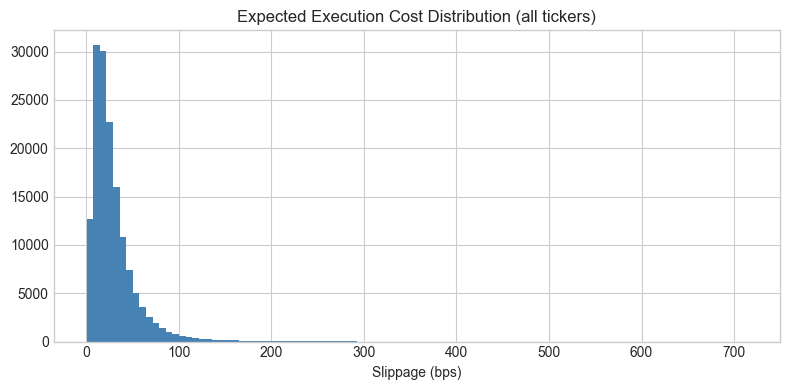

count    150048.000
mean         29.359
std          26.938
min           0.429
25%          13.412
50%          22.272
75%          36.323
max         713.903


In [3]:
# Slippage distribution — now concentrated (no drift heavy tails)
fig, ax = plt.subplots(figsize=(8, 4))
proxy_all['slippage_bps'].hist(bins=100, ax=ax, color='steelblue', edgecolor='none')
ax.set_xlabel('Slippage (bps)')
ax.set_title('Expected Execution Cost Distribution (all tickers)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'slippage_distribution.png', dpi=150)
plt.show()
print(proxy_all['slippage_bps'].describe().round(3).to_string())

In [4]:
# Alpha calibration on SPY via MLP val-MAE.
# For each candidate α, we rebuild the SPY proxy with that α and train a
# short MLP (15 epochs). The α with the lowest validation MAE wins.
# This avoids the circularity of comparing proxy(α) vs proxy(2.0) directly.
spy_df = data['SPY']
spy_mf = compute_market_features(spy_df)

def _build_spy_split(alpha):
    order_rng = np.random.default_rng(_ticker_seed('SPY'))
    proxy_rng = np.random.default_rng(_ticker_seed('SPY') + 1)
    spy_feats = add_synthetic_orders(spy_mf, rng=order_rng)
    proxy = build_proxy(spy_df, spy_feats, alpha=alpha, impact_noise=0.4, rng=proxy_rng)
    return temporal_split(proxy)

alphas = [0.5, 1.0, 2.0, 5.0, 10.0]
print('Running alpha calibration (~25 min on CPU for 5 candidates × 15 epochs)...')
best_alpha, sensitivity = calibrate_alpha(
    _build_spy_split, n_features=len(FEATURE_NAMES_TRAINING),
    alphas=alphas, epochs=15,
)
print(f'Alpha sensitivity (val MAE): {sensitivity}')
print(f'Best alpha: {best_alpha}')

Running alpha calibration (~25 min on CPU for 5 candidates × 15 epochs)...


Alpha sensitivity (val MAE): {0.5: 1.108856439590454, 1.0: 2.285728693008423, 2.0: 4.634429931640625, 5.0: 11.618142127990723, 10.0: 23.405792236328125}
Best alpha: 0.5


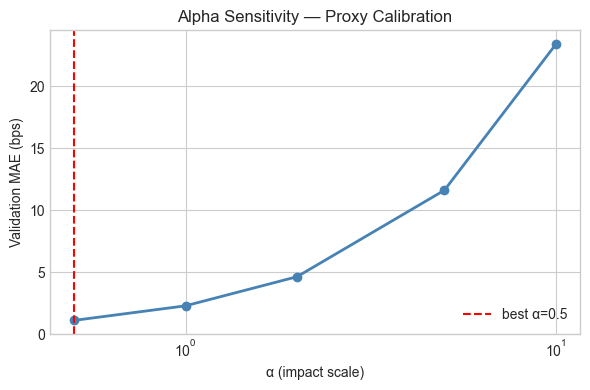

Selected alpha = 0.5  (minimises MAE on validation set)


In [5]:
fig = plot_alpha_sensitivity(
    alphas=[a for a in alphas if a in sensitivity],
    val_maes=[sensitivity[a] for a in alphas if a in sensitivity],
    best_alpha=best_alpha,
    save_as='alpha_sensitivity.png',
)
plt.show()
print(f'Selected alpha = {best_alpha}  (minimises MAE on validation set)')